<a href="https://colab.research.google.com/github/rsekola/Projet_data/blob/master/donn%C3%A9e_visual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Charger le fichier CSV dans un DataFrame
file_path = "Africa_climate_change.csv"
df = pd.read_csv(file_path)

# Afficher un aperçu du DataFrame
df.head()

,DATE,PRCP,TAVG,TMAX,TMIN,COUNTRY
0,19800101 000000,NaN,54.0,61.0,43.0,Tunisia
1,19800101 000000,NaN,49.0,55.0,41.0,Tunisia
2,19800101 000000,0.0,72.0,86.0,59.0,Cameroon
3,19800101 000000,NaN,50.0,55.0,43.0,Tunisia
4,19800101 000000,NaN,75.0,91.0,NaN,Cameroon


In [2]:
# Aperçu avant nettoyage
print("Aperçu avant nettoyage :")
print(df.head(), "\n")

# 1. Suppression des doublons
df_clean = df.drop_duplicates()

# 2. Gestion des valeurs manquantes
# Suppression des lignes avec toutes les valeurs manquantes
df_clean = df_clean.dropna(how='all')

# Remplacement des valeurs manquantes numériques par la moyenne
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].mean())

# Remplacement des valeurs manquantes textuelles par 'Inconnu'
cat_cols = df_clean.select_dtypes(include=['object']).columns
df_clean[cat_cols] = df_clean[cat_cols].fillna("Inconnu")

print("Aperçu après nettoyage :")
print(df_clean.head(), "\n")

print("Résumé des données nettoyées :")
print(df_clean.info())

Aperçu avant nettoyage :
              DATE  PRCP  TAVG  TMAX  TMIN   COUNTRY
0  19800101 000000   NaN  54.0  61.0  43.0   Tunisia
1  19800101 000000   NaN  49.0  55.0  41.0   Tunisia
2  19800101 000000   0.0  72.0  86.0  59.0  Cameroon
3  19800101 000000   NaN  50.0  55.0  43.0   Tunisia
4  19800101 000000   NaN  75.0  91.0   NaN  Cameroon 

Aperçu après nettoyage :
              DATE      PRCP  TAVG  TMAX       TMIN   COUNTRY
0  19800101 000000  0.121253  54.0  61.0  43.000000   Tunisia
1  19800101 000000  0.121253  49.0  55.0  41.000000   Tunisia
2  19800101 000000  0.000000  72.0  86.0  59.000000  Cameroon
3  19800101 000000  0.121253  50.0  55.0  43.000000   Tunisia
4  19800101 000000  0.121253  75.0  91.0  65.545604  Cameroon 

Résumé des données nettoyées :
<class 'pandas.core.frame.DataFrame'>
Index: 462110 entries, 0 to 464814
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   DATE     462110 non-null  object 
 1 

In [5]:
import pandas as pd

df = pd.read_csv("Africa_climate_change.csv")
print(df.columns)

Index(['DATE', 'PRCP', 'TAVG', 'TMAX', 'TMIN', 'COUNTRY'], dtype='object')


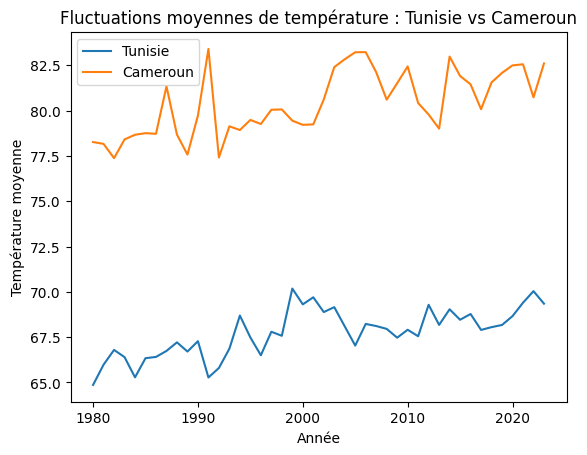

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données
file_path = "Africa_climate_change.csv"
df = pd.read_csv(file_path)

# Conversion de la date et extraction de l'année
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
df["Year"] = df["DATE"].dt.year

# Filtrer pour la Tunisie et le Cameroun
df_filtered = df[df["COUNTRY"].isin(["Tunisia", "Cameroon"])]

# Calcul de la température moyenne annuelle
avg_temp = df_filtered.groupby(["Year", "COUNTRY"])["TAVG"].mean().reset_index()

# Séparation des données
tunisia = avg_temp[avg_temp["COUNTRY"] == "Tunisia"]
cameroon = avg_temp[avg_temp["COUNTRY"] == "Cameroon"]

# Tracé du graphique
plt.figure()
plt.plot(tunisia["Year"], tunisia["TAVG"], label="Tunisie")
plt.plot(cameroon["Year"], cameroon["TAVG"], label="Cameroun")
plt.xlabel("Année")
plt.ylabel("Température moyenne")
plt.title("Fluctuations moyennes de température : Tunisie vs Cameroun")
plt.legend()
plt.show()


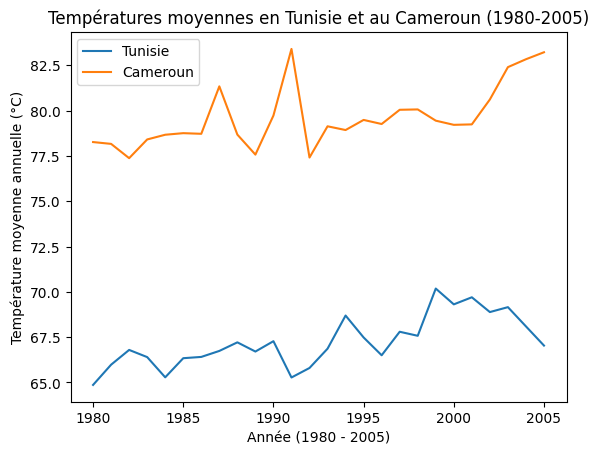

In [9]:
# Préparer la date et l'année
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
df["Year"] = df["DATE"].dt.year

# Filtrer entre 1980 et 2005
df_period = df[(df["Year"] >= 1980) & (df["Year"] <= 2005)]

# Filtrer pour la Tunisie et le Cameroun
df_filtered = df_period[df_period["COUNTRY"].isin(["Tunisia", "Cameroon"])]

# Calculer la moyenne annuelle
avg_temp = df_filtered.groupby(["Year", "COUNTRY"])["TAVG"].mean().reset_index()

tunisia = avg_temp[avg_temp["COUNTRY"] == "Tunisia"]
cameroon = avg_temp[avg_temp["COUNTRY"] == "Cameroon"]

# Tracer le graphique avec personnalisation des axes
plt.figure()
plt.plot(tunisia["Year"], tunisia["TAVG"], label="Tunisie")
plt.plot(cameroon["Year"], cameroon["TAVG"], label="Cameroun")

plt.xlabel("Année (1980 - 2005)")
plt.ylabel("Température moyenne annuelle (°C)")
plt.title("Températures moyennes en Tunisie et au Cameroun (1980-2005)")
plt.legend()

plt.show()

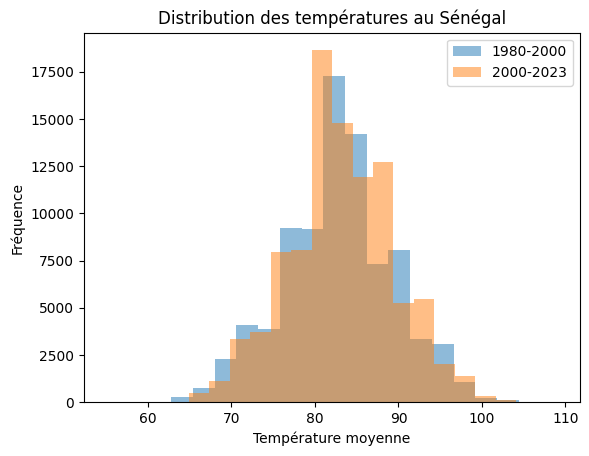

In [10]:
# Préparer la date et l'année
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
df["Year"] = df["DATE"].dt.year

# Filtrer pour le Sénégal
df_sn = df[df["COUNTRY"] == "Senegal"]

# Deux périodes
temp_1980_2000 = df_sn[(df_sn["Year"] >= 1980) & (df_sn["Year"] < 2000)]["TAVG"]
temp_2000_2023 = df_sn[(df_sn["Year"] >= 2000) & (df_sn["Year"] <= 2023)]["TAVG"]

# Créer les histogrammes sur la même figure
plt.figure()
plt.hist(temp_1980_2000, bins=20, alpha=0.5, label="1980-2000")
plt.hist(temp_2000_2023, bins=20, alpha=0.5, label="2000-2023")
plt.xlabel("Température moyenne")
plt.ylabel("Fréquence")
plt.title("Distribution des températures au Sénégal")
plt.legend()
plt.show()

Si l’objectif est de comparer la température moyenne entre plusieurs pays, le diagramme en barres verticales reste la meilleure option pour une lecture claire, rapide et professionnelle.

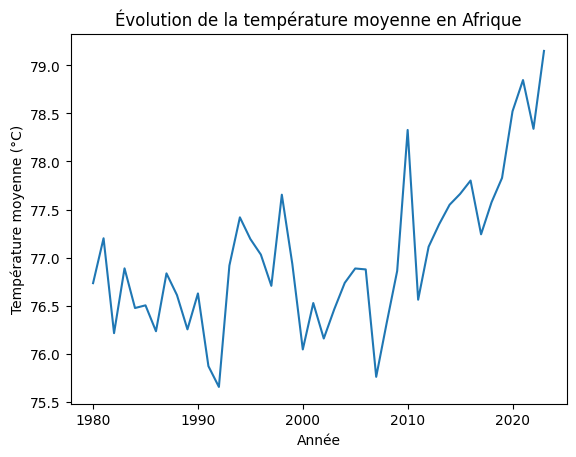

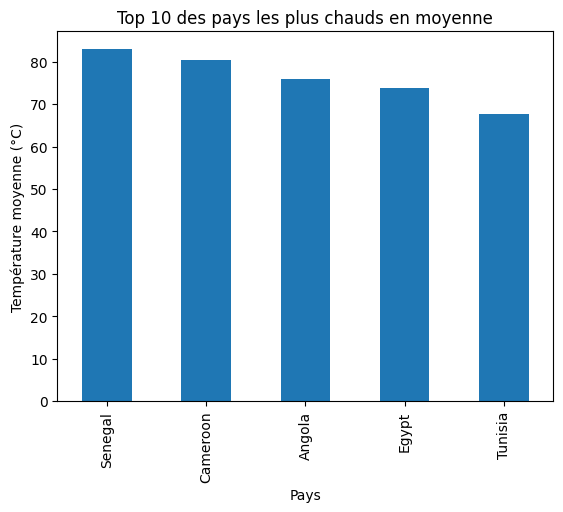

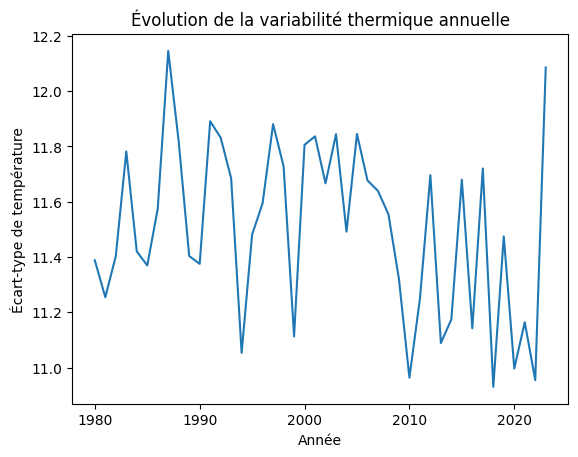

In [11]:
# ------------------ Question 1 ------------------
# Quelles sont les tendances de température moyenne en Afrique au fil du temps ?

avg_africa = df.groupby("Year")["TAVG"].mean()

plt.figure()
plt.plot(avg_africa.index, avg_africa.values)
plt.xlabel("Année")
plt.ylabel("Température moyenne (°C)")
plt.title("Évolution de la température moyenne en Afrique")
plt.show()

# ------------------ Question 2 ------------------
# Quels sont les pays les plus chauds en moyenne ?

avg_by_country = df.groupby("COUNTRY")["TAVG"].mean().sort_values(ascending=False).head(10)

plt.figure()
avg_by_country.plot(kind="bar")
plt.xlabel("Pays")
plt.ylabel("Température moyenne (°C)")
plt.title("Top 10 des pays les plus chauds en moyenne")
plt.show()

# ------------------ Question 3 ------------------
# La variabilité des températures augmente-t-elle avec le temps ?

std_by_year = df.groupby("Year")["TAVG"].std()

plt.figure()
plt.plot(std_by_year.index, std_by_year.values)
plt.xlabel("Année")
plt.ylabel("Écart-type de température")
plt.title("Évolution de la variabilité thermique annuelle")
plt.show()